In [2]:
from PIL import Image, ImageFile
import math
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
card_w = 63
card_h = 88
margin = 3.175

In [3]:
def expand_for_bleed(image: ImageFile) -> Image:
    """ Based on the width and height of the image, expands
        the last row/column of pixels to create a bleed. Does
        this blindly so it assumes it has been preprocessed as much 
        as you want before this

    """
    width, height = image.size
    bleed_pixels_h = math.ceil(margin/card_h * height)
    bleed_pixels_w = math.ceil(margin/card_w * width)
    image_array = np.array(list(image.getdata())).reshape((height,width,-1))[:,:,:3]
    top_bleed = np.tile(image_array[0,...].ravel(),reps=bleed_pixels_w).reshape((bleed_pixels_w,width,3))
    bottom_bleed = np.tile(image_array[-1,...].ravel(),reps=bleed_pixels_w).reshape((bleed_pixels_w,width,3))
    image_array = np.concatenate((top_bleed, image_array, bottom_bleed))
    height = image_array.shape[0]
    left_bleed =  np.repeat(image_array[:,0,...], repeats=bleed_pixels_h, axis=0).reshape((height,bleed_pixels_h,3))
    right_bleed = np.repeat(image_array[:,-1,...],repeats=bleed_pixels_h, axis=0).reshape((height,bleed_pixels_h,3))
    image_array = np.concatenate((left_bleed, image_array, right_bleed),axis=1)
    img_w_bleed = Image.fromarray(np.uint8(image_array))
    return img_w_bleed

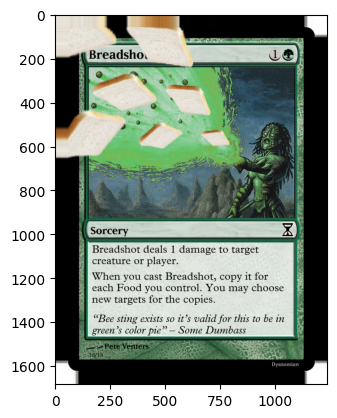

In [4]:
# image_path = (Path(os.path.abspath('')).parent / "downloads") / "draftable_upscaled/1_2_of_Elesh_Norn_Rounded_Up.png"
image_path = (Path(os.path.abspath('')).parent / "downloads") / "draftable_upscaled/Breadshot.png"
reference_border = Image.open(Path(os.path.abspath('')).parent / "MPCReference.png")
img = Image.open(image_path)
img_w_bleed = expand_for_bleed(img)
reference_border = reference_border.resize(img_w_bleed.size)
plt.imshow(img_w_bleed)
# plt.imshow(reference_border)
img_w_bleed.save("TestBleed.png")

# Testing Using the error of a circle to determine corner

Did not work as expected.

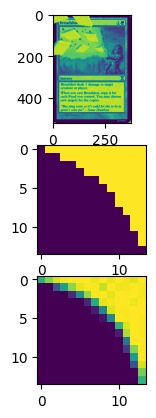

In [5]:
import colorsys
max_radius = 50
image = Image.open((Path(os.path.abspath('')).parent / "downloads") / "draftable/Breadshot.png")
width, height = image.size
image_array = np.array(list(image.getdata())).reshape((height,width,-1))[:,:,:3]

# Detect if there is a corner
def generate_semi_circle(radius: int, top = True, right = True):
    blank_array = np.zeros((radius, radius))
    center_x = radius-1 if top else 0
    center_y = 0 if right else radius-1
    for x in range(radius):
        for y in range(radius):
            if pow(x-center_x,2) + pow(y-center_y,2) >= pow(radius, 2) :
                blank_array[x,y] = 255
    furthest_point =  (math.ceil(math.sqrt(pow(radius, 2) - pow(radius-1,2)))-1)
    if top and right:
        blank_array = blank_array[:-furthest_point,furthest_point:]
    if top and not right:
        pass
        blank_array = blank_array[:-furthest_point,:-furthest_point]
    if not top and right:
        blank_array = blank_array[furthest_point:,furthest_point:]
    if not top and not right:
        blank_array = blank_array[furthest_point:,:-furthest_point]
    return blank_array
possible_semi_circles = list(range(6,max_radius))
image_values = np.asarray([int(colorsys.rgb_to_hsv(*list((point.ravel()/255)))[2]*255) for point in image_array.ravel().reshape((-1,3))]).reshape((height, width))
# Top left
left_errors = []
for radius in possible_semi_circles:
    test_circle = generate_semi_circle(radius,right=False)
    corner_size = test_circle.shape[0]
    error = np.sum(np.pow(image_values[:corner_size, :corner_size]- test_circle, 2))
    left_errors.append(error)
left_errors = np.asarray(left_errors)
left_errors = left_errors[1:] - left_errors[:-1]
# Top Right
right_errors = []
for radius in possible_semi_circles:
    test_circle = generate_semi_circle(radius)
    corner_size = test_circle.shape[0]
    error = np.sum(np.abs(image_values[:corner_size, -corner_size:]- test_circle))
    right_errors.append(error)
right_errors = np.asarray(right_errors)
right_errors = right_errors[1:] - right_errors[:-1]
fig, axes = plt.subplots(3)
axes[0].imshow(image_values)
choosen_radius = possible_semi_circles[right_errors.argmin()] + 4
test_circle = generate_semi_circle(choosen_radius)
corner_size = test_circle.shape[0]
# error = np.sum(np.pow(image_values[:corner_size, -corner_size:]- test_circle, 2))
axes[1].imshow(test_circle)
axes[2].imshow(image_values[:corner_size, -corner_size:])
plt.show()
# plt.imshow(Image.fromarray(np.uint8(image_array)))


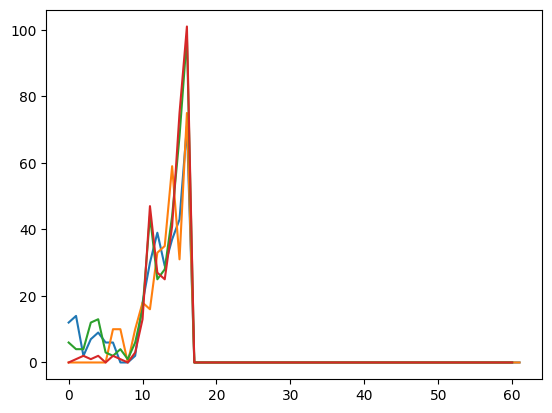

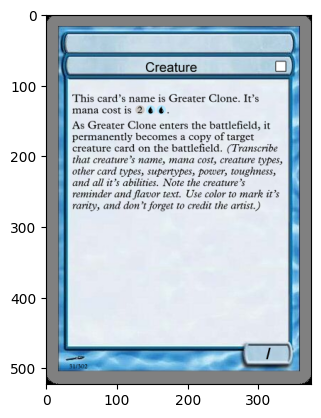

In [12]:
import colorsys
max_radius = 50
image = Image.open((Path(os.path.abspath('')).parent / "downloads") / "draftable/Greater_Clone.png")
width, height = image.size
image_array = np.array(list(image.getdata())).reshape((height,width,-1))[:,:,:3]
image_values = np.asarray([np.asarray(colorsys.rgb_to_hsv(*list((point.ravel()/255))))*255 for point in image_array.ravel().reshape((-1,3))]).reshape((height, width, 3))
def check_corner(image_values, image_array, top=True, right=True):
    height, width = image_values.shape[0:2]
    corner_range_w = [math.floor(width//2 * ratio) for ratio in (0.0, 0.11)]
    corner_range_h = [math.floor(height//2 * ratio) for ratio in (0.0, 0.08)]
    y_flipped = False
    x_flipped = False
    if top and right:
        cropped_image_values = image_values[:height//6, -width//6:,:]
        chunk = np.flip(cropped_image_values, axis=1)
        y_flipped = True
    if top and not right:
        cropped_image_values = image_values[:height//6, 0:width//6,:]
        chunk = cropped_image_values
    if not top and right:
        cropped_image_values = image_values[-height//6::, -width//6:,:]
        chunk = np.flip(np.flip(cropped_image_values, axis=1), axis=0)
        y_flipped = True
        x_flipped = True
    if not top and not right:
        cropped_image_values = image_values[-height//6:, 0:width//6,:]
        chunk = np.flip(cropped_image_values, axis=0)
        x_flipped = True

    horizontal_differences = np.abs(chunk[0,1:,2]-chunk[0,:-1,2])
    horizontal_transition_point = np.argmax(horizontal_differences)
    plt.plot(horizontal_differences)
    vertical_differences = np.abs(chunk[1:,0,2]-chunk[:-1,0,2])
    vertical_transition_point = np.argmax(vertical_differences)

    margin = 3
    if horizontal_transition_point < corner_range_w[1] and horizontal_transition_point > corner_range_w[0] and np.max(horizontal_differences) > 30 and \
        vertical_transition_point < corner_range_h[1] and vertical_transition_point > corner_range_h[0] and np.max(vertical_differences) > 30 and chunk[0,0,2]  > 100:
        further_cropped = chunk[:vertical_transition_point + margin, :horizontal_transition_point + margin]
        sampled_hsv = further_cropped[further_cropped.shape[0]//2, further_cropped.shape[1]//2]

        for x in range(vertical_transition_point + margin):
            for y in range(horizontal_transition_point + margin):
                if further_cropped[x,y,2]  > max(sampled_hsv[2] + 30,0) and further_cropped[x,y,1] < 50:
                    target_x = x
                    target_y = y
                    if x_flipped:
                        target_x = -x - 1
                    if y_flipped:
                        target_y = -y - 1
                    image_array[target_x,target_y] = np.array([0,0,0])
        return True
    else:
        return False
                    
check_corner(image_values, image_array)
check_corner(image_values, image_array, False)
check_corner(image_values, image_array, right=False)
check_corner(image_values, image_array, False, False)
fig, axes = plt.subplots(1)
axes.imshow(image_array)
plt.show()

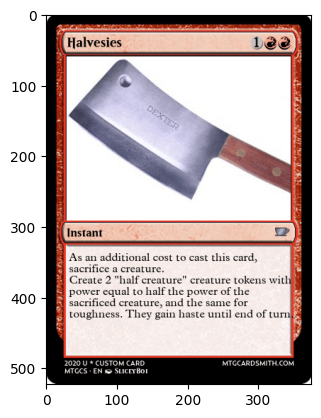

In [7]:
image = Image.open((Path(os.path.abspath('')).parent / "downloads") / "draftable/Halvesies.png")
width, height = image.size
image = image.convert("RGBA")
image_array = np.array(list(image.getdata())).reshape((height,width,-1))[:,:,:3]
plt.imshow(image_array)